In [16]:
# Phase 1: Synthetic Data

In [17]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_users = 5000

user_id = np.arange(1, n_users + 1)
age = np.random.randint(18, 65, size=n_users)
account_balance = np.random.exponential(scale=3000, size=n_users)
activity_score = np.clip(np.random.normal(loc=50, scale=15, size=n_users), 0, 100)
country = np.random.choice(["UK", "France", "Germany", "Poland", "Romania"], size=n_users)

# active, wealthy users are more likely to get the incentive, this is the confounding
propensity = 1 / (1 + np.exp(-(-2 + 0.04 * activity_score + 0.0003 * account_balance)))
treatment = np.random.binomial(1, propensity)

# hidden ground truth, in a real job nobody gets to see this column
true_effect = 5 + 0.15 * activity_score + np.random.normal(0, 1, size=n_users)
baseline_transactions = 10 + 0.3 * activity_score + 0.001 * account_balance + np.random.normal(0, 3, size=n_users)
transactions_after = baseline_transactions + treatment * true_effect

data = pd.DataFrame({
    "user_id": user_id, "age": age, "account_balance": account_balance,
    "activity_score": activity_score, "country": country, "treatment": treatment,
    "baseline_transactions": baseline_transactions, "transactions_after": transactions_after,
    "true_effect": true_effect
})
data.head()

,user_id,age,account_balance,activity_score,country,treatment,baseline_transactions,transactions_after,true_effect
0,1,56,2609.297823,55.736500,Germany,1,33.880964,47.382998,13.502034
1,2,46,14026.506632,30.317552,Poland,1,32.581906,42.832695,10.250789
2,3,32,4240.752084,44.043270,Romania,1,22.988099,34.226854,11.238755
3,4,60,1751.768965,49.377923,Germany,1,24.742918,37.545304,12.802386
4,5,25,3686.815613,33.514412,Germany,1,21.849062,31.891040,10.041978


In [18]:
#Phase 2: Causal Inference Core

In [19]:
# naive comparison ignores confounding, true_effect is our known ground truth to check against
naive_diff = data.groupby("treatment")["transactions_after"].mean()
naive_effect = naive_diff[1] - naive_diff[0]
print("Naive effect:", naive_effect)
print("True effect:", data["true_effect"].mean())

Naive effect: 16.753628982170135
True effect: 12.482760643988417


In [20]:
from sklearn.linear_model import LogisticRegression

features = data[["age", "account_balance", "activity_score"]]

# this model learns who was likely to be treated, we use that to reweight the comparison
prop_model = LogisticRegression()
prop_model.fit(features, data["treatment"])
data["propensity_score"] = prop_model.predict_proba(features)[:, 1]

weight = np.where(data["treatment"] == 1, 1 / data["propensity_score"], 1 / (1 - data["propensity_score"]))
treated_mask, control_mask = data["treatment"] == 1, data["treatment"] == 0

weighted_treated = np.sum(weight[treated_mask] * data["transactions_after"][treated_mask]) / np.sum(weight[treated_mask])
weighted_control = np.sum(weight[control_mask] * data["transactions_after"][control_mask]) / np.sum(weight[control_mask])

ipw_ate = weighted_treated - weighted_control
print("IPW corrected effect:", ipw_ate)

IPW corrected effect: 12.616495023170607


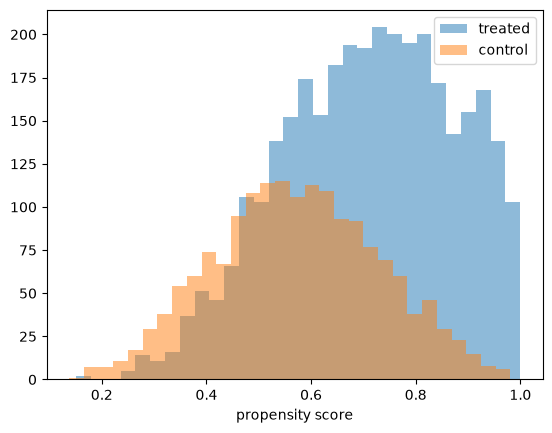

weight range: 1.0003328579651374 52.416150922732974


In [21]:
import matplotlib.pyplot as plt

# check overlap, if treated and control don't share the same propensity range the weighting gets shaky
plt.hist(data[data["treatment"] == 1]["propensity_score"], bins=30, alpha=0.5, label="treated")
plt.hist(data[data["treatment"] == 0]["propensity_score"], bins=30, alpha=0.5, label="control")
plt.legend()
plt.xlabel("propensity score")
plt.show()

print("weight range:", weight.min(), weight.max())

In [22]:
from sklearn.ensemble import RandomForestRegressor

treated_data = data[data["treatment"] == 1]
control_data = data[data["treatment"] == 0]
features_cols = ["age", "account_balance", "activity_score"]

# two forests, one per treatment arm, the gap between their predictions is the individual effect
model_treated = RandomForestRegressor(n_estimators=100, random_state=42)
model_treated.fit(treated_data[features_cols], treated_data["transactions_after"])

model_control = RandomForestRegressor(n_estimators=100, random_state=42)
model_control.fit(control_data[features_cols], control_data["transactions_after"])

data["cate_estimate"] = model_treated.predict(data[features_cols]) - model_control.predict(data[features_cols])

In [23]:
# bucket by activity and compare estimated effect against the hidden true effect
data["activity_bin"] = pd.cut(data["activity_score"], bins=10)
print(data.groupby("activity_bin")[["cate_estimate", "true_effect"]].mean())

               cate_estimate  true_effect
activity_bin                             
(-0.1, 10.0]        5.173249     5.813597
(10.0, 20.0]        7.284317     7.608674
(20.0, 30.0]        9.161137     8.840204
(30.0, 40.0]       10.629680    10.316043
(40.0, 50.0]       12.183329    11.769568
(50.0, 60.0]       13.257297    13.215674
(60.0, 70.0]       15.267546    14.651787
(70.0, 80.0]       16.080324    16.130429
(80.0, 90.0]       18.123019    17.523405
(90.0, 100.0]      22.106319    19.276669


In [24]:
#Phase 3: Conformal Intervals + Validation

In [30]:
from sklearn.model_selection import train_test_split

treated_train, treated_calib = train_test_split(treated_data, test_size=0.3, random_state=42)
control_train, control_calib = train_test_split(control_data, test_size=0.3, random_state=42)

model_treated_conf = RandomForestRegressor(n_estimators=100, random_state=42)
model_treated_conf.fit(treated_train[features_cols], treated_train["transactions_after"])
model_control_conf = RandomForestRegressor(n_estimators=100, random_state=42)
model_control_conf.fit(control_train[features_cols], control_train["transactions_after"])

alpha = 0.1
calib_combined = pd.concat([treated_calib, control_calib])
pred_t = model_treated_conf.predict(calib_combined[features_cols])
pred_c = model_control_conf.predict(calib_combined[features_cols])
pseudo_cate = pred_t - pred_c

# combining the actual residual directly (instead of stacking two separate quantiles) avoids overshooting
actual_outcome_diff = np.where(calib_combined["treatment"] == 1,
                                calib_combined["transactions_after"] - pred_c,
                                pred_t - calib_combined["transactions_after"])
q_combined = np.quantile(np.abs(actual_outcome_diff - pseudo_cate), 1 - alpha)

data["cate_lower"] = data["cate_estimate"] - q_combined
data["cate_upper"] = data["cate_estimate"] + q_combined

covered = (data["true_effect"] >= data["cate_lower"]) & (data["true_effect"] <= data["cate_upper"])
print("interval half-width:", q_combined)
print("empirical coverage:", covered.mean())
with open("q_combined.pkl", "wb") as f:
    pickle.dump(q_combined, f)

interval half-width: 5.505201140158174
empirical coverage: 0.9708


In [31]:
n_rct = 1000
rct_age = np.random.randint(18, 65, size=n_rct)
rct_balance = np.random.exponential(scale=3000, size=n_rct)
rct_activity = np.clip(np.random.normal(loc=50, scale=15, size=n_rct), 0, 100)

# random coin flip assignment, no confounding, this is our gold standard check
rct_treatment = np.random.binomial(1, 0.5, size=n_rct)
rct_true_effect = 5 + 0.15 * rct_activity + np.random.normal(0, 1, size=n_rct)
rct_baseline = 10 + 0.3 * rct_activity + 0.001 * rct_balance + np.random.normal(0, 3, size=n_rct)
rct_outcome = rct_baseline + rct_treatment * rct_true_effect

rct_data = pd.DataFrame({"age": rct_age, "account_balance": rct_balance,
                          "activity_score": rct_activity, "treatment": rct_treatment, "outcome": rct_outcome})

rct_gold_ate = rct_data[rct_data["treatment"] == 1]["outcome"].mean() - rct_data[rct_data["treatment"] == 0]["outcome"].mean()
rct_model_ate = (model_treated_conf.predict(rct_data[features_cols]) - model_control_conf.predict(rct_data[features_cols])).mean()

print("RCT gold standard ATE:", rct_gold_ate)
print("model predicted ATE on RCT users:", rct_model_ate)
print("actual true effect on RCT users:", rct_true_effect.mean())

RCT gold standard ATE: 11.956780899931815
model predicted ATE on RCT users: 12.976103153307314
actual true effect on RCT users: 12.626021056384248


In [32]:
#Phase 4: Deployment + Business Analysis

In [33]:
import pickle

with open("model_treated.pkl", "wb") as f:
    pickle.dump(model_treated_conf, f)
with open("model_control.pkl", "wb") as f:
    pickle.dump(model_control_conf, f)

Naive effect (biased): 16.75
Corrected effect (causal): 12.78


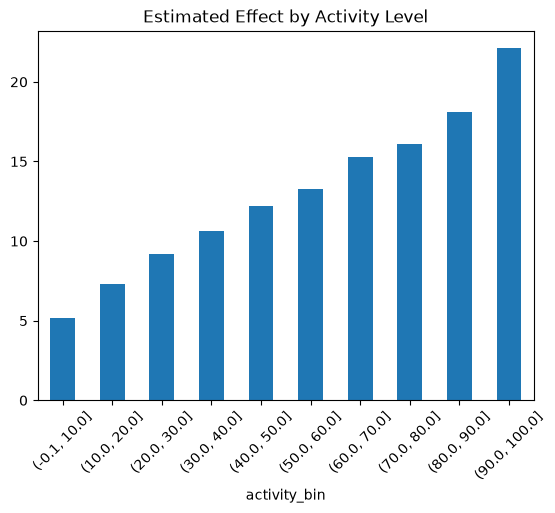

cost=3: targeted=48806.46, blanket=48888.99, targeted_wins=False
cost=4: targeted=43892.46, blanket=43888.99, targeted_wins=True
cost=5: targeted=38978.46, blanket=38888.99, targeted_wins=True
cost=6: targeted=34064.46, blanket=33888.99, targeted_wins=True
cost=7: targeted=29150.46, blanket=28888.99, targeted_wins=True
cost=8: targeted=24236.46, blanket=23888.99, targeted_wins=True
cost=12: targeted=4580.46, blanket=3888.99, targeted_wins=True
cost=16: targeted=-15075.54, blanket=-16111.01, targeted_wins=True
cost=20: targeted=-34731.54, blanket=-36111.01, targeted_wins=True


In [34]:
# final business read: naive vs corrected effect, effect by segment, and the roi crossover point
naive_diff = data.groupby("treatment")["transactions_after"].mean()
print("Naive effect (biased):", round(naive_diff[1] - naive_diff[0], 2))
print("Corrected effect (causal):", round(data["cate_estimate"].mean(), 2))

segment_avg = data.groupby("activity_bin")["cate_estimate"].mean()
fig, ax = plt.subplots()
segment_avg.plot(kind="bar", ax=ax)
plt.xticks(rotation=45)
plt.title("Estimated Effect by Activity Level")
plt.show()

for cost in [3, 4, 5, 6, 7, 8, 12, 16, 20]:
    data["net_value"] = data["cate_estimate"] - cost
    targeted = data[data["cate_lower"] > 0]["net_value"].sum()
    blanket = data["net_value"].sum()
    print(f"cost={cost}: targeted={round(targeted,2)}, blanket={round(blanket,2)}, targeted_wins={targeted > blanket}")

In [35]:
# Phase 5: Limits, Fallback Estimand, and Sensitivity Analysis

In [36]:
# check treatment share per activity decile, near 0 or 1 means barely any comparison group exists there
overlap_by_segment = data.groupby("activity_bin")["treatment"].agg(["mean", "count"])
print(overlap_by_segment)

                   mean  count
activity_bin                  
(-0.1, 10.0]   0.259259     27
(10.0, 20.0]   0.419753     81
(20.0, 30.0]   0.479532    342
(30.0, 40.0]   0.542787    818
(40.0, 50.0]   0.655777   1255
(50.0, 60.0]   0.701797   1224
(60.0, 70.0]   0.767383    791
(70.0, 80.0]   0.806818    352
(80.0, 90.0]   0.887640     89
(90.0, 100.0]  0.857143     21


In [37]:
# restrict to users with propensity in a safe range, this is called trimming to common support
trimmed_data = data[(data["propensity_score"] > 0.1) & (data["propensity_score"] < 0.9)]

trimmed_weight = np.where(trimmed_data["treatment"] == 1, 1 / trimmed_data["propensity_score"], 1 / (1 - trimmed_data["propensity_score"]))
t_mask, c_mask = trimmed_data["treatment"] == 1, trimmed_data["treatment"] == 0

trimmed_treated = np.sum(trimmed_weight[t_mask] * trimmed_data["transactions_after"][t_mask]) / np.sum(trimmed_weight[t_mask])
trimmed_control = np.sum(trimmed_weight[c_mask] * trimmed_data["transactions_after"][c_mask]) / np.sum(trimmed_weight[c_mask])

print("full sample ATE:", ipw_ate)
print("trimmed (common support) ATE:", trimmed_treated - trimmed_control)
print("users dropped:", n_users - len(trimmed_data))

full sample ATE: 12.616495023170607
trimmed (common support) ATE: 12.437604030110002
users dropped: 506


In [39]:
sensitivity_results = []

for strength in [0, 2, 4, 6, 8, 10]:
    np.random.seed(123)
    hidden_confounder = np.random.normal(0, 1, size=n_users)
    fake_logit = -2 + 0.04 * activity_score + 0.0003 * account_balance + strength * 0.1 * hidden_confounder
    fake_propensity = 1 / (1 + np.exp(-fake_logit))
    fake_treatment = np.random.binomial(1, fake_propensity)
    fake_outcome = baseline_transactions + fake_treatment * true_effect + strength * 0.3 * hidden_confounder

    temp_model = LogisticRegression()
    temp_model.fit(features, fake_treatment)
    temp_prop = temp_model.predict_proba(features)[:, 1]

    w = np.where(fake_treatment == 1, 1 / temp_prop, 1 / (1 - temp_prop))
    t_mask, c_mask = fake_treatment == 1, fake_treatment == 0
    est = (np.sum(w[t_mask] * fake_outcome[t_mask]) / np.sum(w[t_mask])) - (np.sum(w[c_mask] * fake_outcome[c_mask]) / np.sum(w[c_mask]))
    sensitivity_results.append((strength, est))

for strength, est in sensitivity_results:
    print(f"confounder strength={strength}: estimated effect={round(est,2)} (true effect is {round(true_effect.mean(),2)})")

confounder strength=0: estimated effect=12.02 (true effect is 12.48)
confounder strength=2: estimated effect=11.82 (true effect is 12.48)
confounder strength=4: estimated effect=12.36 (true effect is 12.48)
confounder strength=6: estimated effect=13.1 (true effect is 12.48)
confounder strength=8: estimated effect=13.88 (true effect is 12.48)
confounder strength=10: estimated effect=14.92 (true effect is 12.48)
